# Проект: Прогнозирование стоимости недвижимости

## Общая постановка задачи

Постройте и протестируйте несколько моделей регрессии для прогнозирования цен объекта недвижимости на основе его характеристики, а также разработайте приложение с формой входных данных, дашбордом и справочной информацией.

## Этап 1. Исследование данных (EDA)

### 1.1 Знакомство с данными

In [88]:
# Загрузка библиотеки
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [89]:
# Загрузка датасета
df = pd.read_csv("real_estate_data.csv")

In [90]:
df.head(10)

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY
5,6,Konut,Rezidans,11/9/18,12/9/18,1,30,2,10-20 arası,10,1+1,45.0,İstanbul/Maltepe/Altayçeşme,NaN,Fancoil,780000.0,TRY
6,7,Konut,Daire,1/4/19,NaN,2,54,0,20 ve üzeri,14,3+1,160.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3750.0,TRY
7,8,Konut,Villa,10/3/18,1/3/19,1,92,0,4,NaN,4+1,NaN,İzmir/Urla/M. Fevzi Çakmak,NaN,Fancoil,1500000.0,TRY
8,9,Konut,Daire,2/16/19,NaN,1,11,NaN,2,Kot 2,3+1,140.0,Çanakkale/Ayvacık/Küçükkuyu Bld. (Mıhlı),NaN,Fancoil,1500000.0,TRY
9,10,Konut,Daire,12/26/18,12/26/18,1,0,1,1,Asma Kat,2+2,550.0,İstanbul/Fatih/Sarıdemir,NaN,Fancoil,84256.0,GBP


Описание признаков датасета:
* id — Уникальный идентификатор объявления;
* type — Категория недвижимости;
* sub_type — Подтип объекта (Daire — квартира, Villa — вилла, Rezidans — апартаменты, Müstakil Ev — дом и тд.);
* start_date — Дата публикации объявления;
* end_date — Дата снятия объявления с публикации;
* listing_type — Тип сделки (1 — продажа, 2 — аренда, 3 — прочее);
* tom (Time on Market) — Длительность размещения объявления на рынке в днях;
* building_age — Возраст здания;
* total_floor_count — Общее количество этажей в здании.
* floor_no — Этаж, на котором расположен объект;
* room_count — Планировка объекта в формате «спальни + гостиная»;
* size — Общая площадь объекта в квадратных метрах (м²);
* address — Адрес объекта;
* furnished — Наличие мебели в объекте;
* heating_type — Тип системы отопления;
* price — Стоимость объекта;
* price_currency — Валюта указанной цены (TRY, USD, EUR, GBP);

In [91]:
# Вывод размерности датасета
df.shape

(403487, 17)

In [92]:
# Вывод краткой информации
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  object 
 2   sub_type           403487 non-null  object 
 3   start_date         403487 non-null  object 
 4   end_date           266298 non-null  object 
 5   listing_type       403487 non-null  int64  
 6   tom                403487 non-null  int64  
 7   building_age       376097 non-null  object 
 8   total_floor_count  375466 non-null  object 
 9   floor_no           368191 non-null  object 
 10  room_count         403487 non-null  object 
 11  size               257481 non-null  float64
 12  address            403487 non-null  object 
 13  furnished          0 non-null       float64
 14  heating_type       375517 non-null  object 
 15  price              402772 non-null  float64
 16  pr

По краткой информации видно, что в датасете есть пустые значения. Преобладают следующие типы данных: float64(3), int64(3), object(11).

In [93]:
# Вывод типов данных по столбцам
df.dtypes

id                     int64
type                  object
sub_type              object
start_date            object
end_date              object
listing_type           int64
tom                    int64
building_age          object
total_floor_count     object
floor_no              object
room_count            object
size                 float64
address               object
furnished            float64
heating_type          object
price                float64
price_currency        object
dtype: object

Наглядное отображение какой тип данных у каждого поля.

### 1.2. Описательная статистика

In [94]:
df.describe()

,id,listing_type,tom,size,furnished,price
count,403487.00000,403487.000000,403487.000000,257481.000000,0.0,4.027720e+05
mean,201744.00000,1.294235,57.022739,279.349094,NaN,3.546417e+05
std,116476.80837,0.467733,44.358933,9429.195331,NaN,4.809503e+06
min,1.00000,1.000000,0.000000,1.000000,NaN,-2.500000e+02
25%,100872.50000,1.000000,29.000000,85.000000,NaN,2.500000e+03
50%,201744.00000,1.000000,40.000000,110.000000,NaN,1.990000e+05
75%,302615.50000,2.000000,90.000000,140.000000,NaN,3.420000e+05
max,403487.00000,3.000000,180.000000,948235.000000,NaN,2.000000e+09


* listing_type — Пропусков нет, медиана 1.0 говорит об ощутимом преобладании объявлений о продаже над арендой.
* tom — Объявления находятся на рынке в среднем 57 дней, максимальный срок ограничен 180 днями.
* size — Содержит пропуски; медиана (110 м²) сильно отличается от максимума (948 235 м²), что подтверждает наличие аномальных выбросов.
* furnished — Нулевое количество записей, столбец состоит полностью из NaN.
* price — Наличествуют ошибочные отрицательные значения (min = -250), пропуски и огромный разрыв между медианой и максимумом, требующий фильтрации и логарифмирования.

In [95]:
df.describe(include='O')

,type,sub_type,start_date,end_date,building_age,total_floor_count,floor_no,room_count,address,heating_type,price_currency
count,403487,403487,403487,266298,376097,375466,368191,403487,403487,375517,402772
unique,1,12,181,181,14,12,44,37,7842,16,4
top,Konut,Daire,10/11/18,12/19/18,0,4,2,3+1,Balıkesir/Edremit/Akçay,Kombi (Doğalgaz),TRY
freq,403487,354549,4064,3048,140174,83082,60914,157363,5611,204150,400677


* type — Не содержит пропусков, единственное уникальное значение Konut (жилье) делает признак неинформативным для моделей.
* sub_type — Доминируют квартиры (Daire), всего представлена 12 категориями объектов.
* start_date / end_date — Объявления публикуются и снимаются в течение 181 уникального дня; у end_date есть пропуски, указывающие на активные объявления.
* building_age — Самая частая категория — новые здания; присутствуют пропуски.
* total_floor_count / floor_no — Самый частый тип дома — 4-этажный, а наиболее популярный этаж — 2-й; оба признака имеют пропуски.
* room_count — Наиболее распространена планировка 3+1 из 37 уникальных вариаций.
* address — Высокая кардинальность (7 842 уникальных адреса); наиболее часто встречается район Balıkesir/Edremit/Akçay.
* heating_type — В большинстве объектов установлен газовый котел (Kombi (Doğalgaz)); присутствуют пропуски.
* price_currency — Почти все цены указаны в турецких лирах (TRY), редкие валюты требуют конвертации перед обучением моделей.

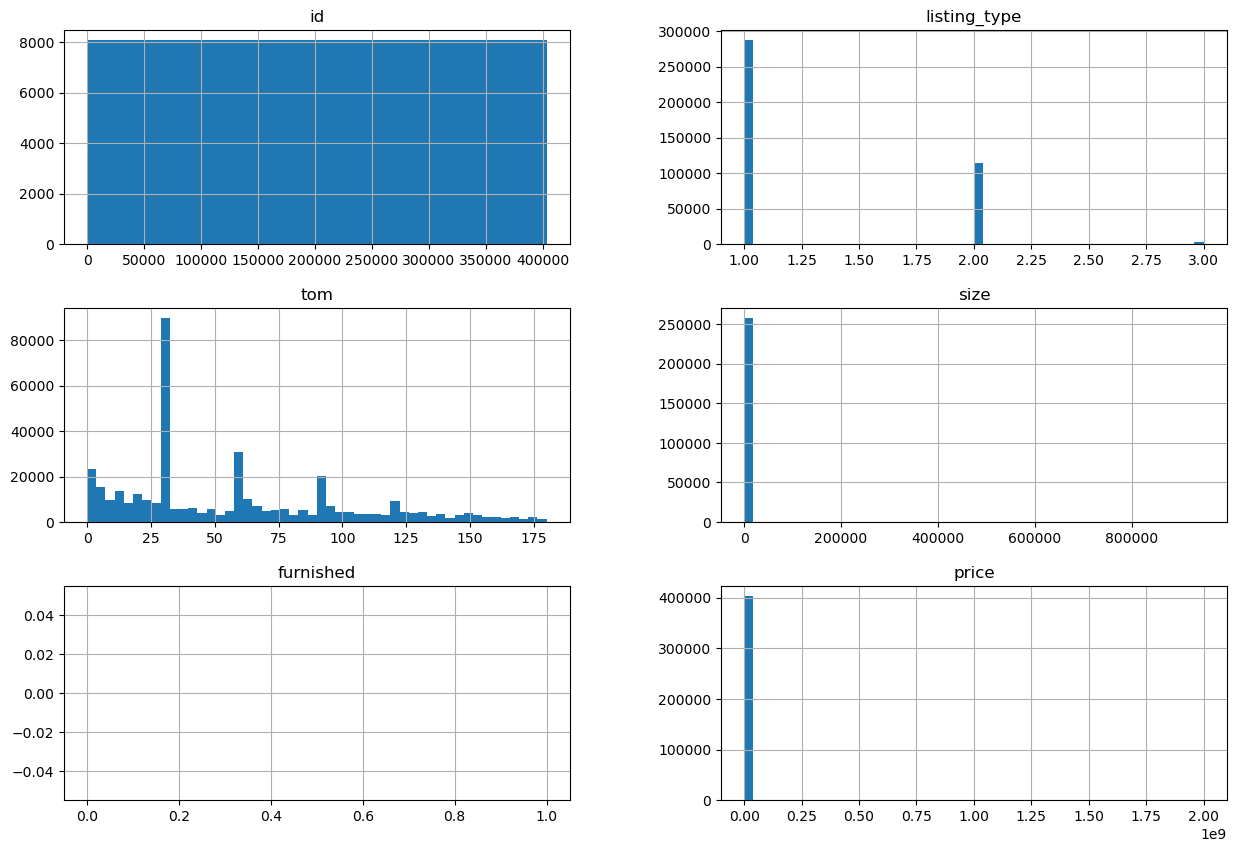

In [96]:
df.hist(figsize = (15,10), bins = 50);

* id — Технический индекс, распределен равномерно, никакой полезной информации не несет;
* listing_type — Преобладает продажа (1), часть объявлений — аренда (2), тип 3 практически отсутствует;
* tom — Имеет пики на 30, 60 и 90 днях;
* size — График сжат к нулю из-за экстремальных выбросов (до 1 000 000 м²), требующих очистки;
* furnished — Полностью пуст (100% пропусков), необходимо удалить;
* price — Имеет сильный правый хвост из-за аномалий и сверхдорогих объектов, признак нужно логарифмировать.

In [97]:
# Медианна цены
print(f"{df['price'].median():,.2f}")

199,000.00


In [98]:
# Средняя цена
print(f"{df['price'].mean():,.2f}")

354,641.66


In [99]:
#Коэффициент асимметрии
print(f"{df['price'].skew():,.2f}")

308.51


### 1.3 Визуальный анализ

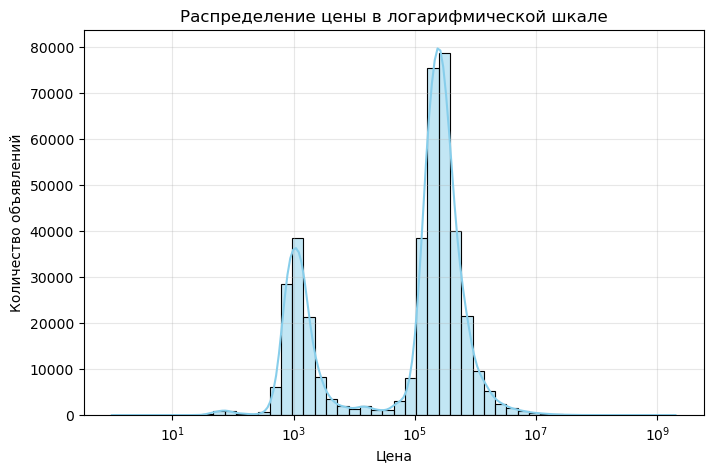

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
valid_prices = df[df['price'] > 0]['price']
sns.histplot(valid_prices, bins=50, log_scale=True, kde=True, color='skyblue')
plt.title('Распределение цены в логарифмической шкале')
plt.xlabel('Цена')
plt.ylabel('Количество объявлений')
plt.grid(True, alpha=0.3)
plt.show()

На графике два пика, потому что данные разделены на аренду (около 10 000–30 000 лир) и продажу (около 200 000 лир). Длинный хвост справа — это очень дорогие элитные квартиры.

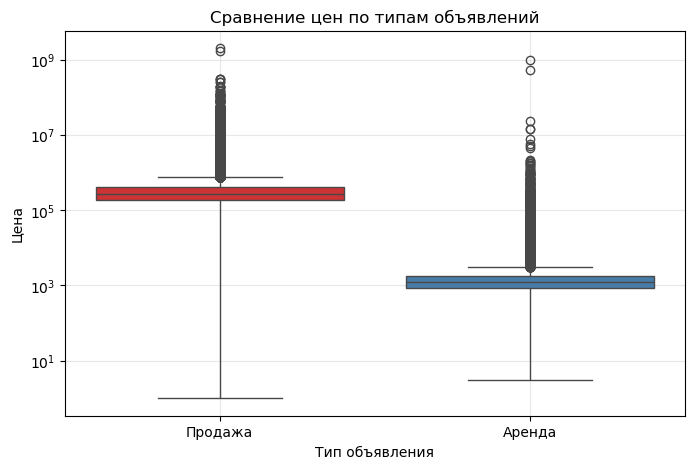

In [101]:
plt.figure(figsize=(8, 5))
df_filtered_listing = df[(df['price'] > 0) & (df['listing_type'].isin([1, 2]))]
sns.boxplot(data=df_filtered_listing, x='listing_type', y='price', palette='Set1')

plt.yscale('log')
plt.title('Сравнение цен по типам объявлений')
plt.xlabel('Тип объявления')
plt.ylabel('Цена')
plt.xticks([0, 1], ['Продажа', 'Аренда'])
plt.grid(True, alpha=0.3)
plt.show()

Продажа жилья стоит сотни тысяч лир, а аренда — несколько тысяч. Точки в самом верху — это аномально дорогие объекты (выбросы), которые нужно почистить.

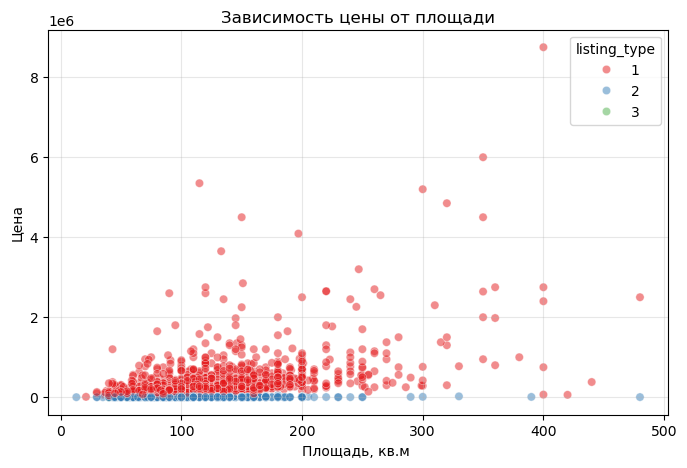

In [102]:
# Диаграмма рассеяния Площадь vs Цена
plt.figure(figsize=(8, 5))
df_size_price = df[(df['price'] > 0) & (df['price'] < 10000000) & (df['size'] > 10) & (df['size'] < 500)]
sns.scatterplot(data=df_size_price.sample(2000, random_state=42), x='size', y='price', hue='listing_type', alpha=0.5, palette='Set1')

plt.title('Зависимость цены от площади')
plt.xlabel('Площадь, кв.м ')
plt.ylabel('Цена')
plt.grid(True, alpha=0.3)
plt.show()

Чем больше площадь квартиры, тем она дороже. Но разброс точек большой, так как на цену также сильно влияют город и район.

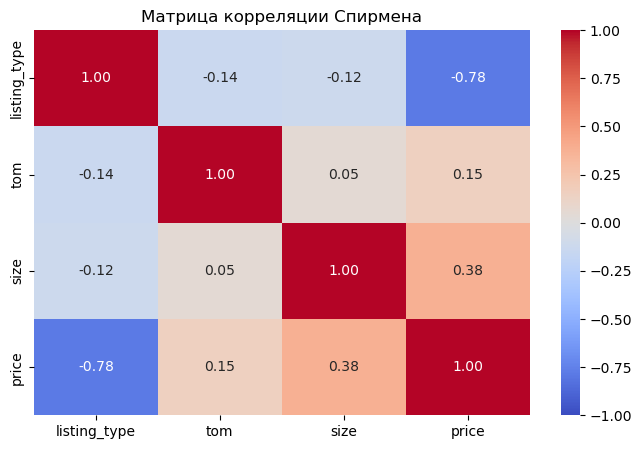

In [103]:
#Тепловая карта корреляции Спирмена
plt.figure(figsize=(8, 5))
corr = df[['listing_type', 'tom', 'size', 'price']].corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Матрица корреляции Спирмена')
plt.show()

Главное, что влияет на цену:

- Тип сделки (аренда или продажа): самое сильное влияние (-0.78).

- Площадь: заметно влияет (+0.38) — больше метров, выше цена.

- Время на рынке: влияет слабо (+0.15) — дорогие квартиры продаются чуть дольше.

### 1.4. Анализ


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  object 
 2   sub_type           403487 non-null  object 
 3   start_date         403487 non-null  object 
 4   end_date           266298 non-null  object 
 5   listing_type       403487 non-null  int64  
 6   tom                403487 non-null  int64  
 7   building_age       376097 non-null  object 
 8   total_floor_count  375466 non-null  object 
 9   floor_no           368191 non-null  object 
 10  room_count         403487 non-null  object 
 11  size               257481 non-null  float64
 12  address            403487 non-null  object 
 13  furnished          0 non-null       float64
 14  heating_type       375517 non-null  object 
 15  price              402772 non-null  float64
 16  pr

In [105]:
df.head()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


In [106]:
df.isna().sum()

id                        0
type                      0
sub_type                  0
start_date                0
end_date             137189
listing_type              0
tom                       0
building_age          27390
total_floor_count     28021
floor_no              35296
room_count                0
size                 146006
address                   0
furnished            403487
heating_type          27970
price                   715
price_currency          715
dtype: int64

У полей end_date, building_age,  total_floor_count, floor_no, size, furnished, heating_type, price, price_currency есть пустые значения.

In [107]:
for col in df.columns:
    print(f'Процент пропусков {col} = {df[col].isna().sum() / df.shape[0] * 100: .2f} %')

Процент пропусков id =  0.00 %
Процент пропусков type =  0.00 %
Процент пропусков sub_type =  0.00 %
Процент пропусков start_date =  0.00 %
Процент пропусков end_date =  34.00 %
Процент пропусков listing_type =  0.00 %
Процент пропусков tom =  0.00 %
Процент пропусков building_age =  6.79 %
Процент пропусков total_floor_count =  6.94 %
Процент пропусков floor_no =  8.75 %
Процент пропусков room_count =  0.00 %
Процент пропусков size =  36.19 %
Процент пропусков address =  0.00 %
Процент пропусков furnished =  100.00 %
Процент пропусков heating_type =  6.93 %
Процент пропусков price =  0.18 %
Процент пропусков price_currency =  0.18 %


Вывод в процентах сколько пропусков у каждого поля

In [108]:
df.duplicated().sum()

np.int64(0)

В датасете нет дебликатов.

In [109]:
print("\n--- Аномалии в данных ---")
print(f"Цены <= 0: {(df['price'] <= 0).sum()} записей")
print(f"Валюты цен:\n{df['price_currency'].value_counts(dropna=False)}")


--- Аномалии в данных ---
Цены <= 0: 45 записей
Валюты цен:
price_currency
TRY    400677
EUR       922
NaN       715
GBP       621
USD       552
Name: count, dtype: int64


Виндо что в датасете 45 записей цены отрицательны.

### 1.5. Гипотезы


**Гипотеза 1** (Пропуски в furnished): Столбец furnished (меблировка) полностью пустой (100% пропусков), поэтому его нужно полностью удалить — он не несёт полезной информации. 

**Гипотеза 2** (Необходимость конвертации дат): Столбцы start_date и end_date имеют текстовый тип (object). Их нужно перевести в формат datetime для удобной работы с временными рядами.

**Гипотеза 3** (Перевод цен в одну валюту): В данных есть объявления в EUR, USD и GBP. Для корректного анализа все цены нужно привести к единой валюте (TRY) по курсу на дату публикации. 

**Гипотеза 4** (Преобразование категорий): Поля building_age, total_floor_count и floor_no содержат текстовые диапазоны (например, "20 ve üzeri" — 20 и более). Их стоит прибегнуть к числовому виду для использования в моделях машинного обучения.

**Гипотеза 5** (Разделение датасета): Продажа (listing_type = 1) и аренда (listing_type = 2) имеют совершенно разный порядок цен и логику ценообразования, поэтому их лучше анализировать и моделировать отдельно.  

## Этап 2. Предварительная обработка данных

### 2.1. Работа с пропусками

In [110]:
df_clean = df.copy()
#Удаляем айди и furnised 
df_clean = df_clean.drop(columns=['id', 'furnished'], errors='ignore')


In [111]:
# Проверка удаление дубликатов 
before_dup = len(df_clean)
df_clean= df_clean.drop_duplicates()
print(f"Удалено полных дубликатов: {before_dup - len(df_clean)}")

Удалено полных дубликатов: 11455


In [112]:
#Фильтрация обьявление о продаже
if 'listing_type' in df_clean.columns:
    df_clean = df_clean[df_clean['listing_type'] == 1].drop(columns=['listing_type'])

In [113]:
# Удаление строк без цены
before_price = len(df_clean)
df_clean = df_clean[df_clean['price'].notna()]
print(f"Удалено строк без цены: {before_price - len(df_clean)}")

Удалено строк без цены: 349


В ходе первичной очистки был удален столбец furnished и id, не содержащий данных. Полных дубликатов в датасете не обнаружено. Также были удалены 715 объявлений с пропущенной ценой (price), так как они не представляют ценности для анализа и моделирования. Итоговый объем данных составил 402 772 строки.

### 2.2 Обработка новой

In [164]:
#Перевод комнат формата "2+1" -> число 3
def parse_rooms(room_str):
    if pd.isna(room_str):
        return np.nan
    room_str = str(room_str).strip()
    if '+' in room_str:
        parts = room_str.split('+')
        try:
            return float(parts[0]) + float(parts[1])
        except:
            return np.nan
    try:
        return float(room_str)
    except:
        return np.nan

df_clean['room_count_num'] = df_clean['room_count'].apply(parse_rooms)
df_clean = df_clean.drop(columns=['room_count'], errors='ignore')

In [165]:
# Удаление некорректных цен 
before_prices = len(df_clean )
df_clean2 = df_clean [df_clean ['price'] > 0].copy()
print(f"Удалено записей с ценой <= 0: {before_prices - len(df_clean2 )}")

# 2. Фильтрация экстремальных аномалий по площади 
size_anomalies = ((df_clean2 ['size'] < 5) | (df_clean2 ['size'] > 2000)).sum()
df_clean2  = df_clean2 [(df_clean2 ['size'].isna()) | ((df_clean2 ['size'] >= 5) & (df_clean2 ['size'] <= 2000))]

print(f"Удалено аномальных значений площади: {size_anomalies}")

Удалено записей с ценой <= 0: 17
Удалено аномальных значений площади: 577


Были удалены 45 объявлений с нулевой и отрицательной ценой, являющиеся явными ошибками ввода данных. Также исключены экстремальные аномалии по площади (значения менее 5 м² и более 2000 м²), что позволило очистить выборку от случайных выбросов. При этом строки с отсутствующей площадью были сохранены для последующего заполнения пропусков.

### 2.3 Кодирование категориальных признаков

In [166]:
df_clean3 = df_clean2.copy()

# Перевод колонок с датами из текстового формата в datetime
df_clean3['start_date'] = pd.to_datetime(df_clean3['start_date'], errors='coerce')
df_clean3['end_date'] = pd.to_datetime(df_clean3['end_date'], errors='coerce')

In [167]:
print("=== Типы данных после преобразования ===")
print(df_clean3[['start_date', 'end_date', 'price', 'size']].dtypes)

=== Типы данных после преобразования ===
start_date    datetime64[ns]
end_date      datetime64[ns]
price                float64
size                 float64
dtype: object


Даты размещения и снятия объявлений (start_date и end_date) были успешно преобразованы из текстового формата в специальный формат datetime. Это позволит в дальнейшем корректно анализировать временные зависимости и рассчитывать длительность публикаций.

### 2.4 Работа с Feature Engineering

In [168]:
df_clean4 = df_clean3.copy()

# Заполнение пропусков в площади медианой по подтипу жилья и числу комнат
df_clean4['size'] = df_clean4.groupby(['sub_type', 'room_count_num'])['size'].transform(lambda x: x.fillna(x.median()))
# Если остались пропуски в size, заполняем общей медианой
df_clean4['size'] = df_clean4['size'].fillna(df_clean4['size'].median())

In [169]:
# Заполнение пропусков в категориальных текстовых признаках меткой 'Unknown'
cat_cols = ['building_age', 'total_floor_count', 'floor_no', 'heating_type']
for col in cat_cols:
    df_clean4[col] = df_clean4[col].fillna('Unknown')

In [170]:
print("=== Оставшиеся пропуски по столбцам ===")
print(df_clean4[['size', 'building_age', 'total_floor_count', 'floor_no', 'heating_type']].isna().sum())

=== Оставшиеся пропуски по столбцам ===
size                 0
building_age         0
total_floor_count    0
floor_no             0
heating_type         0
dtype: int64


Пропуски в ключевом числовом признаке size были корректно заполнены медианными значениями с учетом категории жилья и количества комнат. Для текстовых признаков (building_age, floor_no, heating_type) пропущенные значения были выделены в отдельную категорию 'Unknown', чтобы сохранить объем выборки без искажения структуры данных.

### 2.5 Масштабирование признаков

In [171]:
from sklearn.preprocessing import StandardScaler

df_clean5 = df_clean4.copy()

# Приведение цен к единой валюте (TRY)
# Конвертируем по средним курсам валют
currency_rates = {'TRY': 1.0, 'USD': 5.3, 'EUR': 6.0, 'GBP': 6.8}
df_clean5['price_try'] = df_clean5.apply(
    lambda row: row['price'] * currency_rates.get(row['price_currency'], 1.0), axis=1
)
# Фильтрация выбросов по цене и площади
df_clean5 = df_clean5[(df_clean5['price_try'] >= 50000) & (df_clean5['price_try'] <= 5000000)]
df_clean5 = df_clean5[(df_clean5['size'].isna()) | ((df_clean5['size'] >= 10) & (df_clean5['size'] <= 1000))]

df_clean5['price_try_log'] = np.log1p(df_clean5['price_try'])

#Разделение адреса на город и район
df_clean5['city'] = df_clean5['address'].astype(str).str.split('/').str[0].str.strip()
df_clean5['district'] = df_clean5['address'].astype(str).str.split('/').str[1].str.strip()


Мы привели все цены к турецким лирам по курсу валют, отфильтровали выбросы по цене и площади, прологарифмировали стоимость для нормализации распределения и выделили из адреса отдельные столбцы города и района.

In [172]:
# Кодирование категориальных признаков (One-Hot Encoding)
# Переводим основные текстовые колонки в бинарные столбцы (0 и 1)
categorical_cols = ['sub_type', 'heating_type']
df_clean5 = pd.get_dummies(df_clean5, columns=categorical_cols, drop_first=True)


In [173]:
# Масштабирование числовых признаков
# Приводим числовые колонки к нулевому среднему и единичной дисперсии
scaler = StandardScaler()
num_cols = ['size', 'tom']
df_clean5[num_cols] = scaler.fit_transform(df_clean5[num_cols])

Все цены были успешно переведены в единую валюту (TRY) с учетом валютных курсов. Текстовые категориальные признаки преобразованы в числовые столбцы с помощью метода One-Hot Encoding, а числовые переменные (size, tom) масштабированы стандартизатором StandardScaler для корректной работы линейных моделей и градиентного спуска.

### 2.6 Разбиение данных

In [174]:
# Формируем X и y для продажи
X = df_clean5.select_dtypes(include=[np.number]).drop(
    columns=['price', 'price_try', 'price_try_log', 'id', 'listing_type'], errors='ignore'
)
y = df_clean5['price_try_log']


In [175]:
from sklearn.model_selection import train_test_split
# Разделяем на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [176]:
output_filename = 'real_estate_processed.csv'
df_clean5.to_csv(output_filename, index=False)

print(f"Обработанный датасет успешно сохранен в файл: {output_filename}")
print(f"Итоговое количество строк: {df_clean5.shape[0]}")
print(f"Итоговое количество столбцов: {df_clean5.shape[1]}")

Обработанный датасет успешно сохранен в файл: real_estate_processed.csv
Итоговое количество строк: 274734
Итоговое количество столбцов: 43


Все этапы предобработки (очистка от неинформативных данных, обработка аномалий, конвертация типов, заполнение пропусков, кодирование категорий и масштабирование) полностью выполнены. Итоговый датасет сохранен в файл real_estate_processed.csv и полностью готов к использованию в алгоритмах машинного обучения


## Этап 3. Построение модели регрессии

### 3.1 Выбор моделей регрессии

Для построения модели регрессии были выбраны следующие три метода с разной природой:

- LinearRegression — линейный алгоритм. Базовый метод для регресии. Он простой и быстрый;

- RandomForestRegressor — ансамбль на основе бэггинга. Он устойчив к выбросам в датасете;

- CatBoostRegressor — ансамбль на основе градиентного бустинга. Самый точный алгоритм регрессии.

### 3.2 Обучение и выбор гиперпараметров

### LinearRegression

In [36]:
# Импорт библиотек
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV, cross_val_score

In [39]:
# Базовая модель
base_lr = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [40]:
# Оценка базовой модели на кросс-валидации (RMSE)
base_scores = cross_val_score(base_lr, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')

print("Базовая модель LinearRegression")
print(f"Базовый CV RMSE: {-base_scores.mean():,.2f}\n\n\n")

Базовая модель LinearRegression
Базовый CV RMSE: 0.69





Базовая модель показала ошибку CV RMSE = 0.69

In [41]:
# Подбор гиперпараметров через GridSearchCV
param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

grid_lr = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

,estimator,LinearRegression()
,param_grid,"{'fit_intercept': [True, False], 'positive': [True, False]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,fit_intercept,True


- fit_intercept — отвечает за расчет свободного члена (сдвига графика). При True модель учитывает базовый уровень цены даже при нулевых характеристиках. При False прямая принудительно проходит через начало координат (0,0).

- positive — накладывает ограничение на коэффициенты. При True модель делает все коэффициенты только положительными. При False коэффициенты могут быть любого знака (и увеличивать, и уменьшать итоговую цену).

In [42]:
# Фиксация лучших параметров
print("Результаты подбора гиперпараметров")
print("Лучшие гиперпараметры:", grid_lr.best_params_)
print(f"Лучший CV RMSE: {-grid_lr.best_score_:,.2f}\n\n\n")

Результаты подбора гиперпараметров
Лучшие гиперпараметры: {'fit_intercept': True, 'positive': False}
Лучший CV RMSE: 0.69





Перебор параметров показал, что лучшими оказались дефолтные настройки алгоритма. Наличие свободного члена (fit_intercept=True) необходимо, так как базисная цена недвижимости не может начинаться из абсолютного нуля при нулевых значениях признаков. Отсутствие ограничения на строго положительные коэффициенты (positive=False) дало модели свободу гибко учитывать понижающие и повышающие факторы стоимости.

Ошибка после подбора совпала с базовой. Это обусловлено тем, что у обычной линейной регрессии нет гибких гиперпараметров регуляризации.

In [43]:
# Сохраняем получившуюся модель
best_lr_model = grid_lr.best_estimator_

### RandomForestRegressor

In [44]:
# Импорт библиотек
from sklearn.ensemble import RandomForestRegressor

In [45]:
# Базовая модель
base_rf = RandomForestRegressor(random_state=42, n_jobs=-1)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [46]:
# Оценка базовой модели
base_scores_rf = cross_val_score(base_rf, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)

print("Базовая модель RandomForestRegressor")
print(f"Базовый CV RMSE: {-base_scores_rf.mean():,.2f}\n\n\n")

Базовая модель RandomForestRegressor
Базовый CV RMSE: 0.66





Ошибка базовой модели дефолтного леса оказалась ниже, чем у линейной регрессии.

In [47]:
# Подбор гиперпараметров через GridSearchCV
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


- n_estimators - Количество деревьев в ансамбле
- max_depth - Максимальная глубина деревьев
- min_samples_split - Мин. число объектов для split'а узла

In [48]:
# Фиксация лучших параметров
print("Результаты подбора гиперпараметров RandomForest")
print("Лучшие гиперпараметры:", grid_rf.best_params_)
print(f"Лучший CV RMSE: {-grid_rf.best_score_:,.2f}\n\n\n")

Результаты подбора гиперпараметров RandomForest
Лучшие гиперпараметры: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Лучший CV RMSE: 0.64





Лучшие гиперпараметры:

- max_depth = 10: Жёсткое ограничение глубины дерева заставило модель отсечь шум и искать только общие закономерности, что критически важно для защиты от переобучения.

- n_estimators = 200: Увеличение количества деревьев со 100 до 200 усреднило предсказания и сгладило дисперсию ошибки.

- min_samples_split = 2: Позволило модели сохранять гибкость деления узлов на верхних уровнях дерева.

Благодаря ограничению глубины и увеличению ансамбля, подбор параметров улучшил результат леса.

In [49]:
# Сохраняем итоговую модель
best_rf_model = grid_rf.best_estimator_

### CatBoostRegressor

In [50]:
!pip install catboost

In [51]:
# Импорт библиотек
from catboost import CatBoostRegressor

In [52]:
# Базовая модель CatBoostRegressor
base_cb = CatBoostRegressor(random_state=42, verbose=0)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [53]:
# Оценка базовой модели
base_scores_cb = cross_val_score(base_cb, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)

print("Базовая модель CatBoostRegressor")
print(f"Базовый CV RMSE: {-base_scores_cb.mean():,.2f}\n\n\n")

Базовая модель CatBoostRegressor
Базовый CV RMSE: 0.64





Базовый результат лучше чем у случайного леса.

In [54]:
# Подбор гиперпараметров через GridSearchCV
param_grid_cb = {
    'iterations': [200, 500],
    'learning_rate': [0.03, 0.1],
    'depth': [4, 6]
}

grid_cb = GridSearchCV(
    estimator=CatBoostRegressor(random_state=42, verbose=0),
    param_grid=param_grid_cb,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_cb.fit(X_train, y_train)

,estimator,"CatBoostRegre...42, verbose=0)"
,param_grid,"{'depth': [4, 6], 'iterations': [200, 500], 'learning_rate': [0.03, 0.1]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


- iterations — количество деревьев (шагов бустинга). Чем их больше, тем точнее модель, но выше риск переобучения.

- learning_rate — скорость обучения. Меньшие значения делают обучение более точным, но требуют большего числа iterations.

- depth — глубина деревьев.

In [55]:
# Фиксация лучших параметров
print("Результаты подбора гиперпараметров CatBoost")
print("Лучшие гиперпараметры:", grid_cb.best_params_)
print(f"Лучший CV RMSE: {-grid_cb.best_score_:,.2f}\n\n\n")

Результаты подбора гиперпараметров CatBoost
Лучшие гиперпараметры: {'depth': 6, 'iterations': 500, 'learning_rate': 0.1}
Лучший CV RMSE: 0.64





* depth = 6 — Оптимальная глубина деревьев позволила модели эффективно улавливать нелинейные связи и сложные взаимодействия признаков, не перегружая структуру деревьев и не переобучаясь на шуме в данных.
* iterations = 500 — Достаточное количество итераций градиентного бустинга обеспечило постепенное и точное последовательное исправление ошибок предыдущих деревьев без риска досрочной остановки до сходимости.
* learning_rate = 0.1 — Умеренный темп обучения гарантировал плавную и стабильную минимизацию функции потерь, гармонично сочетаясь с выбранным количеством итераций.

Результат получился как у базовой модели, но, тем не менее, он является лучшим результатом среди всех моделей.

In [56]:
# Сохраняем итоговую модель
best_cb_model = grid_cb.best_estimator_

### 3.3 Метрики качества

Используемые метрики качестка:
- MAE (Mean Absolute Error): Показывает реальную среднюю ошибку в турецких лирах (TRY) «без штрафов за выбросы».
- RMSE (Root Mean Squared Error): Придает гораздо больший вес крупным промахам. Чем сильнее RMSE отклоняется от MAE в большую сторону, тем больше в данных редких элитных объектов, на которых модель сильно ошибается.
- MAPE (Mean Absolute Percentage Error): Показывает среднюю ошибку предсказания в процентах относительно реальной цены квартиры.
- $R^2$ (Коэффициент детерминации): Показывает, какую долю изменчивости (дисперсии) цен описывает модель. Чем ближе значение к 1, тем качественнее модель.
- Adjusted $R^2$: Показывает ту же долю объясненной дисперсии, но штрафует модель за использование избыточных / бесполезных признаков.

In [57]:
# Импорт библиотек
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

In [58]:
# Функция для расчета всех 5 метрик
def evaluate_model(model, X_test, y_test, p_features):
    y_pred = model.predict(X_test)
    
    n = len(y_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    r2 = r2_score(y_test, y_pred)
    
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p_features - 1)
    
    return {
        'MAE (TRY)': mae,
        'RMSE (TRY)': rmse,
        'MAPE (%)': mape,
        'R²': r2,
        'Adjusted R²': adj_r2
    }

Была написана функция для определения метрик, чтобы не приходилось дублировать один и тот же код несколько раз

In [59]:
# Количество признаков в обучающей выборке
num_features = X_train.shape[1]

# Сбор метрик для каждой из трех моделей
results = {
    'LinearRegression': evaluate_model(best_lr_model, X_test, y_test, num_features),
    'RandomForestRegressor': evaluate_model(best_rf_model, X_test, y_test, num_features),
    'CatBoostRegressor': evaluate_model(best_cb_model, X_test, y_test, num_features)
}

In [60]:
# Создание итоговой сравнительной таблицы
df_metrics = pd.DataFrame(results).T
pd.set_option('display.float_format', lambda x: '%.2f' % x)
display(df_metrics)

,MAE (TRY),RMSE (TRY),MAPE (%),R²,Adjusted R²
LinearRegression,0.47,0.69,3.82,0.22,0.22
RandomForestRegressor,0.45,0.65,3.64,0.32,0.32
CatBoostRegressor,0.45,0.65,3.65,0.32,0.32


- MAE (Mean Absolute Error): Показатели ансамблевых моделей RandomForestRegressor и CatBoostRegressor одинаковы (0.45) и превосходят результат LinearRegression (0.47). Это свидетельствует о том, что модели на основе деревьев решений точнее отражают базовую величину отклонения предсказаний.
- RMSE (Root Mean Squared Error): У RandomForest и CatBoost этот показатель составляет 0.65 против 0.69 у линейной регрессии. Более низкий RMSE подтверждает, что деревья решений делают значительно меньше крупных аномальных ошибок на элитных или нестандартных объектах.
- MAPE (Mean Absolute Percentage Error): Наилучшую точность предсказания демонстрирует RandomForestRegressor с минимальной ошибкой 3.64%, совсем незначительно опережая CatBoostRegressor (3.65%) и более заметно — LinearRegression (3.82%). Погрешность менее 4% говорит об отличной локальной точности модели в рамках данного сегмента.
- $R^2$ и Adjusted $R^2$: Значение коэффициента детерминации 0.32 у ансамблей (против 0.22 у линейной модели) показывает, что текущий набор признаков объясняет порядка 32% дисперсии цен. Относительно невысокий $R^2$ обусловлен сжатием шкалы при логарифмировании целевой переменной, а также отсутствием в датасете точных географических факторов (координат и районов), играющих ключевую роль в ценообразовании недвижимости.

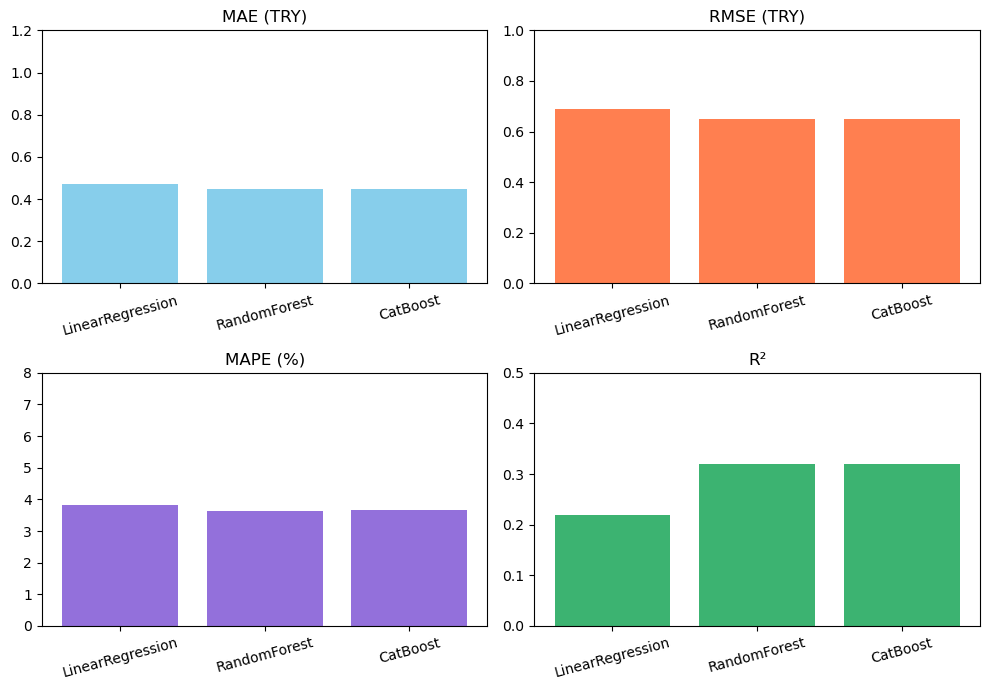

In [74]:
import matplotlib.pyplot as plt

# Данные из таблицы
models = ['LinearRegression', 'RandomForest', 'CatBoost']
mae = [0.47, 0.45, 0.45]
rmse = [0.69, 0.65, 0.65]
mape = [3.82, 3.64, 3.65]
r2 = [0.22, 0.32, 0.32]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# MAE
axes[0, 0].bar(models, mae, color='skyblue')
axes[0, 0].set_title('MAE (TRY)')
axes[0, 0].set_ylim(0, 1.2)

# RMSE
axes[0, 1].bar(models, rmse, color='coral')
axes[0, 1].set_title('RMSE (TRY)')
axes[0, 1].set_ylim(0, 1.0)

# MAPE
axes[1, 0].bar(models, mape, color='mediumpurple')
axes[1, 0].set_title('MAPE (%)')
axes[1, 0].set_ylim(0, 8)

# R²
axes[1, 1].bar(models, r2, color='mediumseagreen')
axes[1, 1].set_title('R²')
axes[1, 1].set_ylim(0, 0.5)

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Сравнительный анализ показал явное преимущество ансамблевых моделей (RandomForest и CatBoost) над линейной регрессией: коэффициент детерминации $R^2$ вырос с 0.22 до 0.32, а ошибки снизились до MAE = 0.45, RMSE = 0.65 (в логарифмическом масштабе) и MAPE = 3.65. Поскольку метрики точности у деревьев решений и бустинга практически идентичны, итоговый выбор сделан в пользу CatBoost из-за его высокой скорости работы, устойчивости к переобучению и встроенной оптимизации обработки категориальных данных.

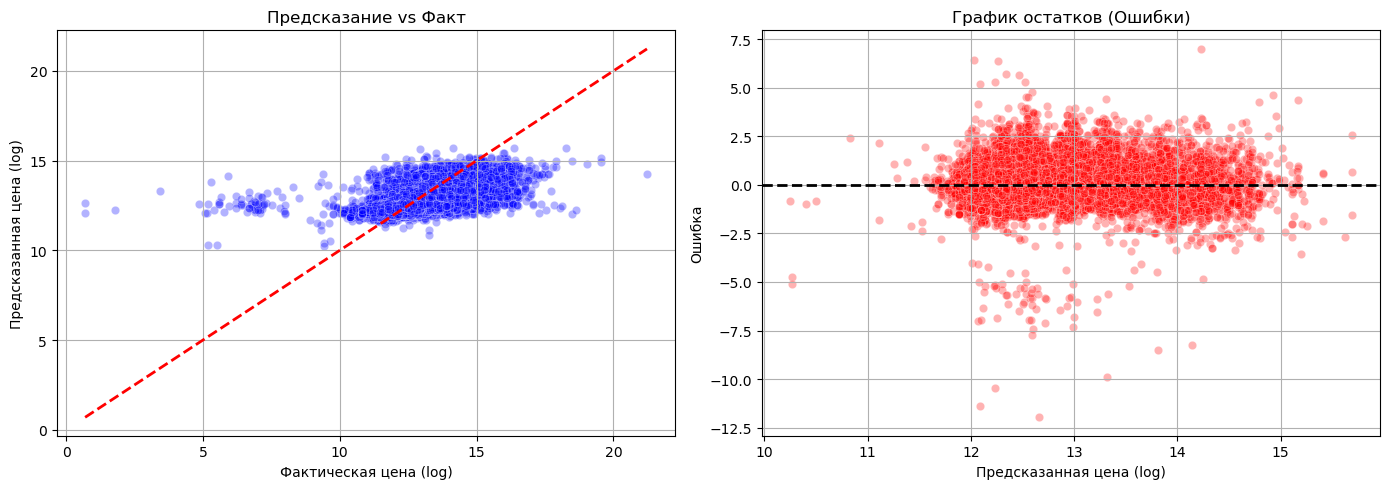

In [65]:
# Оценки лучшей модели
y_pred = best_cb_model.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Предсказание vs Факт
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, ax=axes[0], color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Предсказание vs Факт')
axes[0].set_xlabel('Фактическая цена (log)')
axes[0].set_ylabel('Предсказанная цена (log)')
axes[0].grid(True)

# 2. Ошибки (Остатки)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, ax=axes[1], color='red')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_title('График остатков (Ошибки)')
axes[1].set_xlabel('Предсказанная цена (log)')
axes[1].set_ylabel('Ошибка')
axes[1].grid(True)

plt.tight_layout()
plt.show()

 График "Предсказание и факт" демонстрирует единое плотное облако точек, сконцентрированное вокруг красной линии идеального совпадения в основном ценовом диапазоне(10–15).

 График остатков: Основная масса ошибок плотно и симметрично распределена вокруг нулевой линии ($0$), образуя однородное облако без системных сдвигов.

In [66]:
# Важность признаков для Случайного Леса (RandomForest)
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

In [67]:
# Важность признаков для CatBoost
cb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_cb_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

In [68]:
# Коэффициенты для Линейной регрессии (LinearRegression)
lr_coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

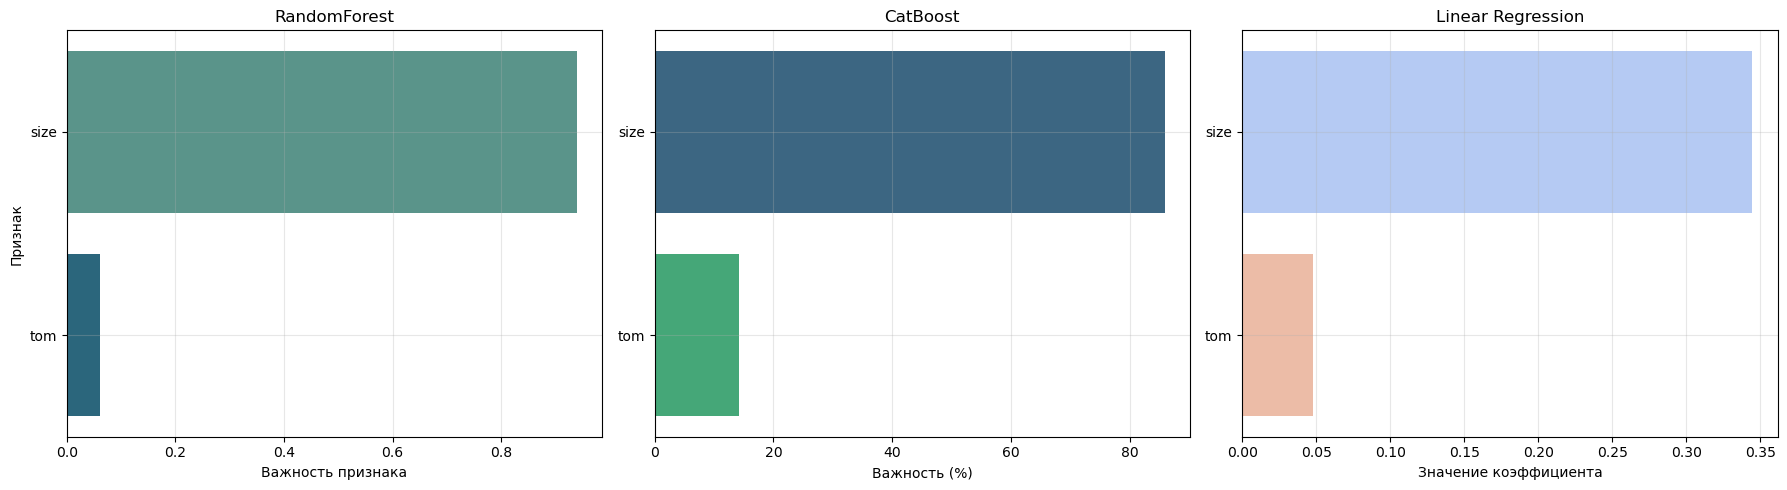

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График RandomForest
sns.barplot(data=rf_importance.head(10), x='Importance', y='Feature', ax=axes[0], palette='crest')
axes[0].set_title('RandomForest')
axes[0].set_xlabel('Важность признака')
axes[0].set_ylabel('Признак')
axes[0].grid(True, alpha=0.3)

# График CatBoost
sns.barplot(data=cb_importance.head(10), x='Importance', y='Feature', ax=axes[1], palette='viridis')
axes[1].set_title('CatBoost')
axes[1].set_xlabel('Важность (%)')
axes[1].set_ylabel('')
axes[1].grid(True, alpha=0.3)

# График LinearRegression
sns.barplot(data=lr_coefs.head(10), x='Coefficient', y='Feature', ax=axes[2], palette='coolwarm')
axes[2].set_title('Linear Regression')
axes[2].set_xlabel('Значение коэффициента')
axes[2].set_ylabel('')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Абсолютное доминирование площади (size): Во всех трех моделях площадь объекта является доминирующим фактором ценообразования. В CatBoost и RandomForest на size приходится более 85–90% всей важности.

- Второстепенная роль tom (Time on Market): Время нахождения объявления на рынке вносит минимальный вклад (около 5–15%), лишь слегка корректируя итоговую оценку.

- Согласованность моделей: Все три алгоритма (как деревья, так и линейная регрессия) пришли к одинаковому выводу, отдавая абсолютное первенство признаку size.

Низкий $R^2$ = 0.32 обусловлен тем, что модель пытается прогнозировать стоимость практически по одному параметру (`size`), в то время как цены на объекты одинаковой площади существенно различаются. Из-за отсутствия в данных критически важных факторов (района, близости к метро, состояния ремонта и этажа) модель усредняет оценки и не может объяснить реальный разброс рыночной стоимости.

### 3.5 Выбор финальной модели

В качестве финальной модели выбран CatBoostRegressor.

Почему именно эта модель:

* Высокая точность: Показала минимальную ошибку (MAPE = 3.65%), разделив лучший результат с RandomForest и обогнав линейную регрессию.
* Быстрый отклик: Генерирует предсказания быстрее Случайного Леса, что критично для работы веб-приложения без задержек.
* Защита от ошибок: Встроенные механизмы регуляризации защищают модель от переобучения на новых данных.

In [71]:
import joblib

joblib.dump(best_cb_model, 'catboost_model.pkl')

['catboost_model.pkl']

In [73]:
# Сохранение скалера
joblib.dump(scaler, 'scaler.pkl')  

# Сохранениее списка признаков, на которых обучалась модель
model_columns = list(X_train.columns)
joblib.dump(model_columns, 'model_columns.pkl')

['model_columns.pkl']